Section 7: Modeling with Structured Data
=========================================
Replicates exactly the methodology from:
"Enhancing mortality prediction in cardiac arrest ICU patients
 through meta-modeling of structured clinical data from MIMIC-IV"

Dependencies: numpy, pandas, sklearn, scipy, matplotlib

Pipeline:
  1. LASSO + GradientBoosting feature selection
  2. Univariate screening (p < 0.05)
  3. VIF multicollinearity check -> drop INR
  4. Three multivariate logistic regression models
  5. Evaluation: AUC-ROC, Calibration, Decision Curve Analysis
  6. NEWS2 benchmark

In [ ]:
# Importing libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, roc_curve,
                             accuracy_score, f1_score, recall_score)
from sklearn.calibration import calibration_curve
from scipy import stats
import numpy.linalg as la

In [ ]:
# Helper

def logit_with_inference(X, y, max_iter=1000):
    """Fit logistic regression; return (clf, coefs, se, pvals, pseudo_r2)."""
    clf = LogisticRegression(penalty=None, solver="lbfgs",
                             max_iter=max_iter, random_state=42)
    clf.fit(X, y)
    coefs = np.concatenate([clf.intercept_, clf.coef_[0]])
    p_hat = clf.predict_proba(X)[:, 1]
    W     = p_hat * (1 - p_hat)
    Xa    = np.c_[np.ones(len(X)), X]
    try:
        cov = la.inv(Xa.T @ (W[:, None] * Xa))
        se  = np.sqrt(np.diag(cov))
    except la.LinAlgError:
        se  = np.full_like(coefs, np.nan)
    z     = coefs / (se + 1e-12)
    pvals = 2 * (1 - stats.norm.cdf(np.abs(z)))
    ll_m  = np.sum(y*np.log(p_hat+1e-12) + (1-y)*np.log(1-p_hat+1e-12))
    p0    = y.mean()
    ll_0  = (y*np.log(p0) + (1-y)*np.log(1-p0)).sum()
    return clf, coefs, se, pvals, 1 - ll_m / ll_0


def compute_vif(X_df):
    """OLS-based VIF for each column."""
    X = X_df.values.astype(float)
    n = X.shape[0]
    vif = {}
    for j, col in enumerate(X_df.columns):
        others = np.delete(X, j, axis=1)
        Xa     = np.c_[np.ones(n), others]
        beta   = la.lstsq(Xa, X[:, j], rcond=None)[0]
        ss_res = np.sum((X[:, j] - Xa @ beta)**2)
        ss_tot = np.sum((X[:, j] - X[:, j].mean())**2)
        r2     = 1 - ss_res / (ss_tot + 1e-12)
        vif[col] = round(1 / (1 - r2 + 1e-12), 2)
    return pd.Series(vif).sort_values(ascending=False)


def std_nb(y_true, y_prob, thresholds):
    """Compute standardized net benefit for DCA."""
    n, prev = len(y_true), y_true.mean()
    nb = []
    for t in thresholds:
        if t >= 1: nb.append(np.nan); continue
        pred = (y_prob >= t).astype(int)
        tp = ((pred==1)&(y_true==1)).sum()
        fp = ((pred==1)&(y_true==0)).sum()
        nb.append((tp/n - fp/n*(t/(1-t+1e-9))) / prev)
    return np.array(nb)


def get_metrics(y_true, y_prob, t=0.5):
    yp = (y_prob >= t).astype(int)
    return {
        "AUC":      round(roc_auc_score(y_true, y_prob), 4),
        "Accuracy": round(accuracy_score(y_true, yp), 4),
        "F1":       round(f1_score(y_true, yp), 4),
        "Recall":   round(recall_score(y_true, yp), 4),
    }

In [ ]:
# Loading data

df = pd.read_excel("C:/Users/amang/rt2/mimic_final_dataset1.xlsx")
print(f"\nDataset: {df.shape}  |  Mortality:\n{df['mortality'].value_counts()}\n")


Dataset: (2307, 102)  |  Mortality:
mortality
1    1207
0    1100
Name: count, dtype: int64



In [ ]:
# Feature Columns

VITAL      = ["hr_mean","sbp_mean","dbp_mean","mbp_mean","rr_mean","bt_mean","spo2_mean"]
LABS       = ["anion_gap_mean","bicarbonate_mean","bun_mean","calcium_mean","chloride_mean",
              "creatinine_mean","glucose_mean","hematocrit_mean","hemoglobin_mean",
              "inr_mean","lactate_mean","ph_mean","platelet_mean","potassium_mean",
              "pt_mean","sodium_mean","wbc_mean"]
COMORBID   = ["copd","heart_failure","diabetes","hypertension"]
TREATMENT  = ["received_ventilation","epinephrine","dopamine"]
GCS        = ["gcs_total"]
DEMO       = ["anchor_age"]
ALL_FEAT   = VITAL + LABS + COMORBID + TREATMENT + GCS + DEMO

TARGET = "mortality"
data   = df[ALL_FEAT + [TARGET]].dropna(subset=[TARGET]).copy()
X_all  = data[ALL_FEAT].values.astype(float)
y_all  = data[TARGET].values.astype(int)
print(f"Features: {len(ALL_FEAT)}  |  N={len(y_all)}  |  Deaths={y_all.sum()}")

Features: 33  |  N=2307  |  Deaths=1207


In [ ]:
# Train/Val Split (80/20 stratified)

X_tr, X_va, y_tr, y_va = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_tr_df = pd.DataFrame(X_tr, columns=ALL_FEAT)
X_va_df = pd.DataFrame(X_va, columns=ALL_FEAT)
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_va_sc = scaler.transform(X_va)
print(f"Train: {len(y_tr)}  |  Val: {len(y_va)}")

Train: 1845  |  Val: 462


In [ ]:
# Step 1 -- Feature Selection

print("\n" + "-"*50)
print("STEP 1: FEATURE SELECTION")
print("-"*50)

# LASSO (L1, 10-fold CV, SAGA solver, binomial deviance = neg_log_loss)
lasso_cv = LogisticRegressionCV(
    Cs=50, cv=10, penalty="l1", solver="saga",
    scoring="neg_log_loss", max_iter=5000, random_state=42, n_jobs=-1)
lasso_cv.fit(X_tr_sc, y_tr)
lasso_coef_arr = lasso_cv.coef_[0]
lasso_feat     = [ALL_FEAT[i] for i in range(len(ALL_FEAT)) if lasso_coef_arr[i] != 0]
print(f"\nLASSO: {len(lasso_feat)} non-zero\n  {lasso_feat}")

# GradientBoosting (XGBoost proxy: max_depth=3, lr=0.05, 100 trees, subsample=0.8)
gb = GradientBoostingClassifier(max_depth=3, learning_rate=0.05,
                                n_estimators=100, subsample=0.8, random_state=42)
gb.fit(X_tr_sc, y_tr)
gb_imp   = pd.Series(gb.feature_importances_, index=ALL_FEAT).sort_values(ascending=False)
n_top    = max(len(lasso_feat), 15)
xgb_feat = list(gb_imp.head(n_top).index)
print(f"\nGradientBoosting top-{n_top}:\n  {xgb_feat}")

candidates = list(set(lasso_feat) | set(xgb_feat))
print(f"\nConsolidated: {len(candidates)} unique predictors")


--------------------------------------------------
STEP 1: FEATURE SELECTION
--------------------------------------------------

LASSO: 27 non-zero
  ['hr_mean', 'dbp_mean', 'rr_mean', 'bt_mean', 'spo2_mean', 'bicarbonate_mean', 'bun_mean', 'calcium_mean', 'chloride_mean', 'creatinine_mean', 'glucose_mean', 'hemoglobin_mean', 'inr_mean', 'lactate_mean', 'ph_mean', 'platelet_mean', 'potassium_mean', 'pt_mean', 'sodium_mean', 'wbc_mean', 'copd', 'diabetes', 'received_ventilation', 'epinephrine', 'dopamine', 'gcs_total', 'anchor_age']

GradientBoosting top-27:
  ['gcs_total', 'lactate_mean', 'bicarbonate_mean', 'ph_mean', 'platelet_mean', 'anchor_age', 'pt_mean', 'hr_mean', 'calcium_mean', 'spo2_mean', 'wbc_mean', 'potassium_mean', 'bun_mean', 'glucose_mean', 'creatinine_mean', 'sodium_mean', 'dbp_mean', 'mbp_mean', 'received_ventilation', 'chloride_mean', 'anion_gap_mean', 'rr_mean', 'bt_mean', 'hemoglobin_mean', 'inr_mean', 'hematocrit_mean', 'sbp_mean']

Consolidated: 31 unique predic

In [ ]:
# Step 2 -- Univariate Screening

print("\n" + "-"*50)
print("STEP 2: UNIVARIATE SCREENING (p < 0.05)")
print("-"*50)

rows = []
for feat in candidates:
    xc = X_tr_df[feat].values.reshape(-1,1)
    _, coefs_uv, se_uv, pvals_uv, _ = logit_with_inference(xc, y_tr)
    rows.append({"Variable": feat,
                 "Coefficient": round(coefs_uv[1], 4),
                 "P-value":     round(pvals_uv[1], 4)})
uvr_df  = pd.DataFrame(rows).sort_values("P-value")
sig_all = list(uvr_df[uvr_df["P-value"] < 0.05]["Variable"])
print(f"\nSignificant: {len(sig_all)} / {len(candidates)}")
print(uvr_df.to_string(index=False))


--------------------------------------------------
STEP 2: UNIVARIATE SCREENING (p < 0.05)
--------------------------------------------------

Significant: 25 / 31
            Variable  Coefficient  P-value
             rr_mean       0.0883   0.0000
        glucose_mean       0.0113   0.0000
    bicarbonate_mean      -0.2141   0.0000
            mbp_mean      -0.0169   0.0000
            bun_mean       0.0183   0.0000
            sbp_mean      -0.0127   0.0000
     creatinine_mean       0.1407   0.0000
             bt_mean      -0.2605   0.0000
       platelet_mean      -0.0035   0.0000
             pt_mean       0.0838   0.0000
             ph_mean      -9.7385   0.0000
         epinephrine       0.6453   0.0000
      potassium_mean       0.8168   0.0000
        lactate_mean       0.5203   0.0000
            wbc_mean       0.0892   0.0000
            inr_mean       0.0187   0.0000
      anion_gap_mean       0.1909   0.0000
           spo2_mean      -0.1128   0.0000
             hr_me

In [ ]:
# Step 3 -- VIF

print("\n" + "-"*50)
print("STEP 3: VIF — MULTICOLLINEARITY")
print("-"*50)

vif_b = compute_vif(X_tr_df[sig_all])
print("\nInitial VIF scores:")
print(vif_b.to_string())

# ── Iterative VIF pruning: drop highest-VIF feature above threshold ──
# We follow the paper's logic (drop one at a time, re-check) but let the
# DATA decide which features to drop, not a hardcoded name.
# mbp_mean is physiologically derived from sbp+dbp, so it is the natural
# first candidate; the loop handles any remaining high-VIF features.
VIF_THRESHOLD = 5.0
sig_clean = sig_all.copy()
dropped_feats = []

while True:
    vif_iter = compute_vif(X_tr_df[sig_clean])
    worst_feat = vif_iter.index[0]          # highest VIF
    worst_val  = vif_iter.iloc[0]
    if worst_val <= VIF_THRESHOLD:
        break
    print(f"\n-> Dropping '{worst_feat}' (VIF={worst_val:.2f} > {VIF_THRESHOLD})")
    sig_clean.remove(worst_feat)
    dropped_feats.append(worst_feat)

print(f"\nDropped features (VIF > {VIF_THRESHOLD}): {dropped_feats}")
vif_a = compute_vif(X_tr_df[sig_clean])
print("\nFinal VIF scores (all <= 5):")
print(vif_a.to_string())


--------------------------------------------------
STEP 3: VIF — MULTICOLLINEARITY
--------------------------------------------------

Initial VIF scores:
mbp_mean                10.80
dbp_mean                 7.13
anion_gap_mean           3.94
bicarbonate_mean         3.26
lactate_mean             3.11
sbp_mean                 2.93
ph_mean                  2.40
gcs_total                2.03
creatinine_mean          2.02
bun_mean                 1.78
chloride_mean            1.74
received_ventilation     1.62
pt_mean                  1.41
glucose_mean             1.32
potassium_mean           1.31
inr_mean                 1.30
spo2_mean                1.30
rr_mean                  1.27
wbc_mean                 1.26
hr_mean                  1.26
anchor_age               1.23
epinephrine              1.22
platelet_mean            1.18
calcium_mean             1.12
bt_mean                  1.08

-> Dropping 'mbp_mean' (VIF=10.80 > 5.0)

Dropped features (VIF > 5.0): ['mbp_mean']

Final V

In [ ]:
# Step 4 -- Three Multivariate Logistic Regression Models

print("\n" + "-"*50)
print("STEP 4: MULTIVARIATE LOGISTIC REGRESSION")
print("-"*50)

def run_model(feats, label):
    feats = [f for f in feats if f in sig_clean]
    clf, coefs, se, pvals, pr2 = logit_with_inference(
        X_tr_df[feats].values.astype(float), y_tr)
    print(f"\n{'='*45}")
    print(f"{label}  |  N features={len(feats)}  |  Pseudo-R2={pr2:.4f}")
    tbl = pd.DataFrame({"Variable": feats,
                         "Coefficient": coefs[1:].round(4),
                         "P-value":     pvals[1:].round(4)})
    print(tbl.to_string(index=False))
    proba = clf.predict_proba(X_va_df[feats].values.astype(float))[:, 1]
    return clf, feats, proba

lasso_sig = [f for f in lasso_feat if f in sig_clean]
xgb_sig   = [f for f in xgb_feat   if f in sig_clean]

clf_lasso,  fl, prob_lasso   = run_model(lasso_sig,  "LASSO-Based Model")
clf_xgb_lr, fx, prob_xgb_lr = run_model(xgb_sig,    "XGBoost-Based Model")
clf_full,   ff, prob_full    = run_model(sig_clean,   "Full Combined Model")


--------------------------------------------------
STEP 4: MULTIVARIATE LOGISTIC REGRESSION
--------------------------------------------------

LASSO-Based Model  |  N features=22  |  Pseudo-R2=0.3582
            Variable  Coefficient  P-value
             hr_mean       0.0189   0.0000
            dbp_mean      -0.0128   0.0178
             rr_mean      -0.0095   0.5369
             bt_mean      -0.0382   0.2904
           spo2_mean      -0.0246   0.1836
    bicarbonate_mean      -0.0690   0.0006
            bun_mean       0.0156   0.0001
        calcium_mean      -0.1058   0.0458
       chloride_mean      -0.0110   0.3861
     creatinine_mean      -0.1890   0.0009
        glucose_mean       0.0016   0.2722
            inr_mean       0.0019   0.5976
        lactate_mean       0.3458   0.0000
             ph_mean       0.9979   0.3066
       platelet_mean      -0.0018   0.0194
      potassium_mean       0.5375   0.0015
             pt_mean       0.0163   0.1499
            wbc_mean    

In [ ]:
# Step 4 -- NEWS2 Benchmark

print("\n" + "-"*50)
print("STEP 5: NEWS2 BENCHMARK")
print("-"*50)

def news2(row):
    s = 0
    rr = row.get("rr_mean", np.nan)
    if not np.isnan(rr):
        s += 3 if rr<=8 else (1 if rr<=11 else (0 if rr<=20 else (2 if rr<=24 else 3)))
    sp = row.get("spo2_mean", np.nan)
    if not np.isnan(sp):
        s += 3 if sp<=91 else (2 if sp<=93 else (1 if sp<=95 else 0))
    sb = row.get("sbp_mean", np.nan)
    if not np.isnan(sb):
        s += 3 if sb<=90 else (2 if sb<=100 else (1 if sb<=110 else (0 if sb<=219 else 3)))
    hr = row.get("hr_mean", np.nan)
    if not np.isnan(hr):
        s += 3 if hr<=40 else (1 if hr<=50 else (0 if hr<=90 else (1 if hr<=110 else (2 if hr<=130 else 3))))
    bt = row.get("bt_mean", np.nan)   # Fahrenheit
    if not np.isnan(bt):
        s += 3 if bt<=95.0 else (1 if bt<=96.8 else (0 if bt<=100.4 else (1 if bt<=102.2 else 2)))
    gc = row.get("gcs_total", np.nan)
    if not np.isnan(gc):
        s += 3 if gc<=14 else 0
    return s

n2_tr  = np.array([news2(X_tr_df.iloc[i].to_dict()) for i in range(len(X_tr_df))])
n2_va  = np.array([news2(X_va_df.iloc[i].to_dict()) for i in range(len(X_va_df))])
clf_n2 = LogisticRegression(penalty=None, solver="lbfgs", max_iter=500, random_state=42)
clf_n2.fit(n2_tr.reshape(-1,1), y_tr)
prob_n2 = clf_n2.predict_proba(n2_va.reshape(-1,1))[:, 1]
prob_gb = gb.predict_proba(X_va_sc)[:, 1]
print(f"NEWS2 AUC: {roc_auc_score(y_va, prob_n2):.4f}")


--------------------------------------------------
STEP 5: NEWS2 BENCHMARK
--------------------------------------------------
NEWS2 AUC: 0.6842


In [ ]:
# Evaluation

print("\n" + "-"*50)
print("STEP 6: EVALUATION METRICS")
print("-"*50)

all_results = {
    "LASSO-LR":       get_metrics(y_va, prob_lasso),
    "XGBoost-LR":     get_metrics(y_va, prob_xgb_lr),
    "Full-LR":        get_metrics(y_va, prob_full),
    "GradBoost(XGB)": get_metrics(y_va, prob_gb),
    "NEWS2":          get_metrics(y_va, prob_n2),
}
print("\nValidation Metrics:")
print(pd.DataFrame(all_results).T.to_string())


--------------------------------------------------
STEP 6: EVALUATION METRICS
--------------------------------------------------

Validation Metrics:
                   AUC  Accuracy      F1  Recall
LASSO-LR        0.8625    0.7922  0.8017  0.8017
XGBoost-LR      0.8581    0.7900  0.8000  0.8017
Full-LR         0.8627    0.8030  0.8131  0.8182
GradBoost(XGB)  0.8736    0.8074  0.8172  0.8223
NEWS2           0.6842    0.6580  0.6914  0.7314


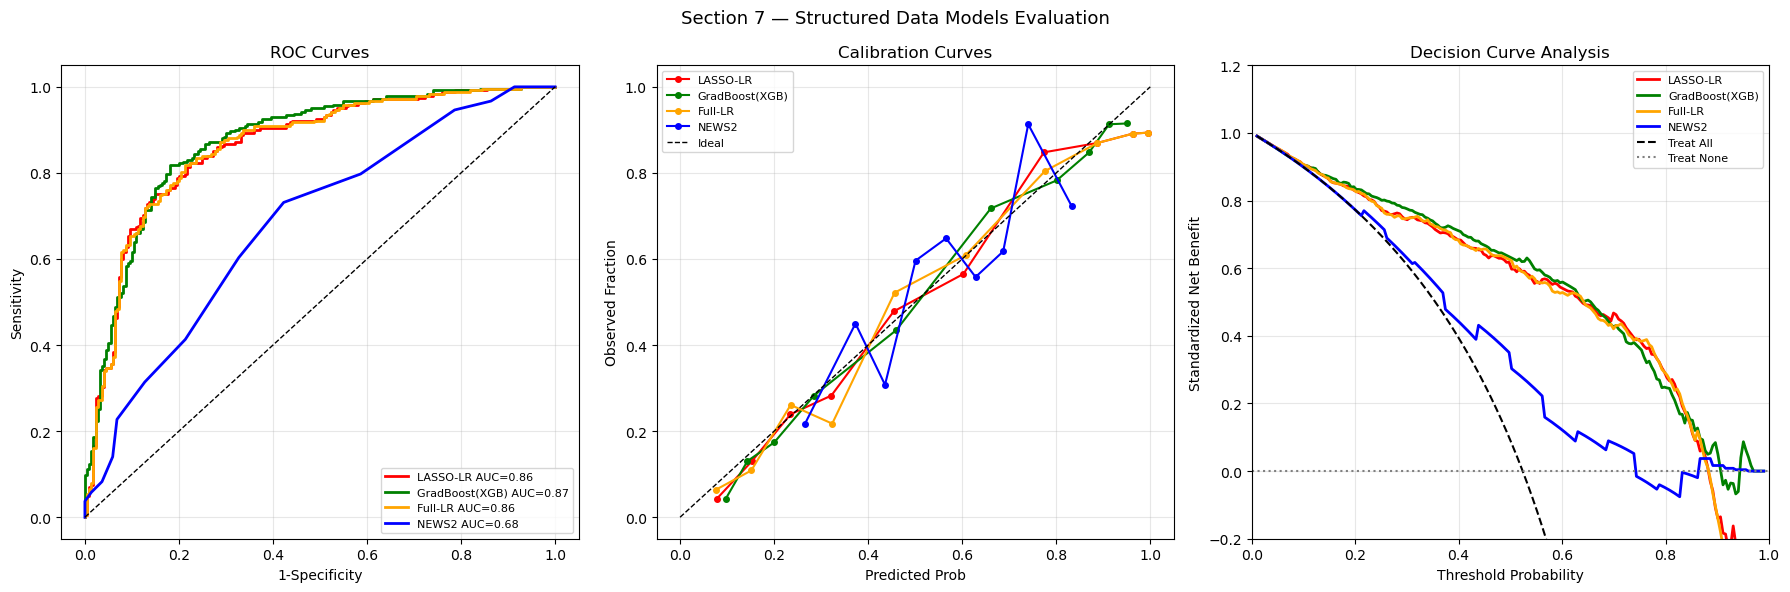

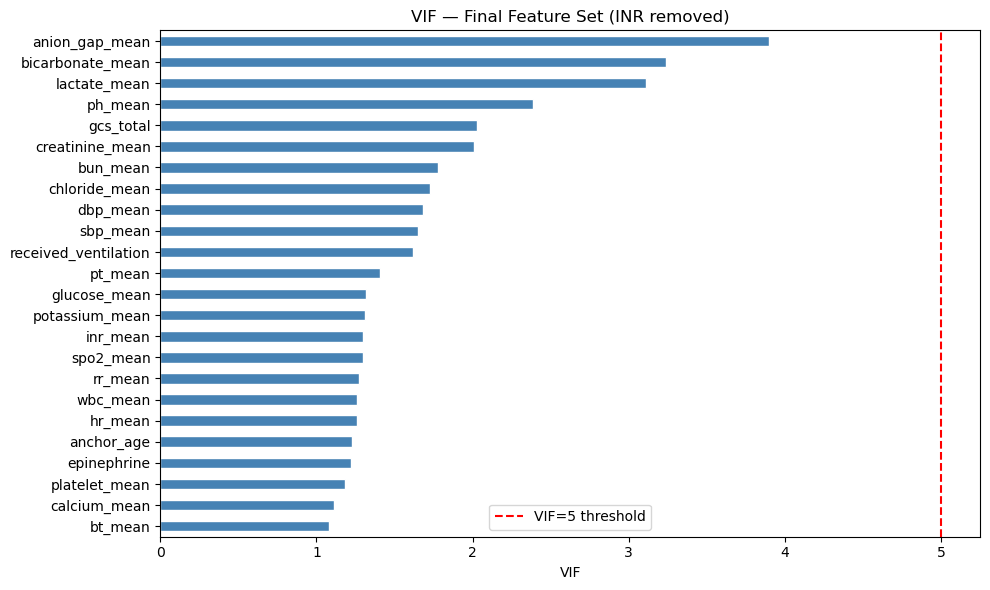

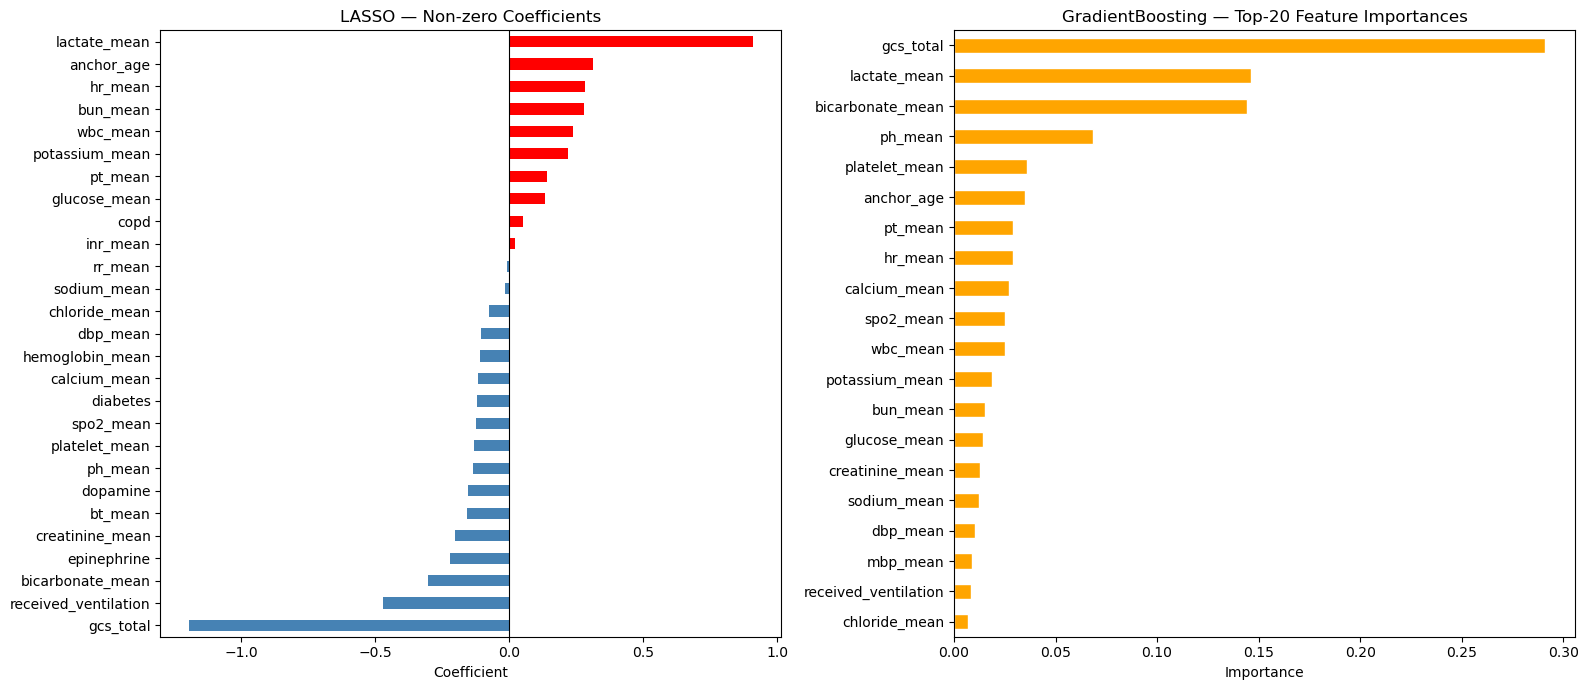

In [ ]:
# Plots

MODEL_MAP = {
    "LASSO-LR":       ("red",    prob_lasso),
    "GradBoost(XGB)": ("green",  prob_gb),
    "Full-LR":        ("orange", prob_full),
    "NEWS2":          ("blue",   prob_n2),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Section 7 — Structured Data Models Evaluation", fontsize=13)

# ROC
ax = axes[0]
for name, (col, prob) in MODEL_MAP.items():
    auc = roc_auc_score(y_va, prob)
    fpr, tpr, _ = roc_curve(y_va, prob)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"{name} AUC={auc:.2f}")
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_xlabel("1-Specificity"); ax.set_ylabel("Sensitivity")
ax.set_title("ROC Curves"); ax.legend(loc="lower right",fontsize=8); ax.grid(alpha=0.3)

# Calibration
ax = axes[1]
for name, (col, prob) in MODEL_MAP.items():
    fr, mp = calibration_curve(y_va, prob, n_bins=10, strategy="quantile")
    ax.plot(mp, fr, "o-", color=col, lw=1.5, ms=4, label=name)
ax.plot([0,1],[0,1],"k--",lw=1,label="Ideal")
ax.set_xlabel("Predicted Prob"); ax.set_ylabel("Observed Fraction")
ax.set_title("Calibration Curves"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# DCA
thresholds = np.linspace(0.01, 0.99, 200)
prev = y_va.mean()
ax = axes[2]
for name, (col, prob) in MODEL_MAP.items():
    ax.plot(thresholds, std_nb(y_va, prob, thresholds), color=col, lw=2, label=name)
treat_all = (prev - (1-prev)*thresholds/(1-thresholds+1e-9)) / prev
ax.plot(thresholds, treat_all, "k--", lw=1.5, label="Treat All")
ax.axhline(0, color="gray", lw=1.5, linestyle=":", label="Treat None")
ax.set_xlim(0,1); ax.set_ylim(-0.2,1.2)
ax.set_xlabel("Threshold Probability"); ax.set_ylabel("Standardized Net Benefit")
ax.set_title("Decision Curve Analysis"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# VIF plot
fig2, ax2 = plt.subplots(figsize=(10,6))
vif_a.sort_values().plot(kind="barh", ax=ax2, color="steelblue", edgecolor="white")
ax2.axvline(5, color="red", linestyle="--", lw=1.5, label="VIF=5 threshold")
ax2.set_title("VIF — Final Feature Set (INR removed)"); ax2.set_xlabel("VIF"); ax2.legend()
plt.tight_layout()
plt.show()

# Feature importance
fig3, ax3 = plt.subplots(1, 2, figsize=(16,7))
nz = pd.Series(lasso_coef_arr, index=ALL_FEAT)
nz = nz[nz!=0].sort_values()
nz.plot(kind="barh", ax=ax3[0], color=["red" if v>0 else "steelblue" for v in nz])
ax3[0].axvline(0, color="black", lw=0.8)
ax3[0].set_title("LASSO — Non-zero Coefficients"); ax3[0].set_xlabel("Coefficient")
gb_imp.head(20).sort_values().plot(kind="barh", ax=ax3[1], color="orange", edgecolor="white")
ax3[1].set_title("GradientBoosting — Top-20 Feature Importances"); ax3[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Summary

print("\n" + "="*60)
print("FINAL MODEL COMPARISON TABLE")
print("="*60)
keys = ["LASSO-LR","XGBoost-LR","Full-LR","GradBoost(XGB)","NEWS2"]
n_feats = [len(fl), len(fx), len(ff), len(ALL_FEAT), 6]
print(pd.DataFrame({
    "Model":     keys,
    "# Feats":   n_feats,
    "AUC":      [all_results[m]["AUC"]      for m in keys],
    "Accuracy": [all_results[m]["Accuracy"] for m in keys],
    "F1":       [all_results[m]["F1"]       for m in keys],
    "Recall":   [all_results[m]["Recall"]   for m in keys],
}).to_string(index=False))
print("\nDone.")


FINAL MODEL COMPARISON TABLE
         Model  # Feats    AUC  Accuracy     F1  Recall
      LASSO-LR       22 0.8625    0.7922 0.8017  0.8017
    XGBoost-LR       23 0.8581    0.7900 0.8000  0.8017
       Full-LR       24 0.8627    0.8030 0.8131  0.8182
GradBoost(XGB)       33 0.8736    0.8074 0.8172  0.8223
         NEWS2        6 0.6842    0.6580 0.6914  0.7314

Done.
